# Kapitel 4 – Fråga 15

### Klassificera egna handskrivna siffror med MNIST

Jag utgår från kodexempel 1 i boken men skalar ner flödet till det som behövs här:

`MNIST -> train/test -> StandardScaler -> ExtraTrees -> egna bilder -> preprocessing -> predict`

In [43]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image, ImageOps

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

### 1. Ladda MNIST

Precis som i bokens exempel använder jag de första 10 000 observationerna för att hålla körtiden nere.

In [44]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist["data"][:10000]
y = mnist["target"][:10000].astype(np.uint8)

print(X.shape)
print(y.shape)

(10000, 784)
(10000,)


### 2. Dela data, skala och träna modellen

Jag använder `StandardScaler` och `ExtraTreesClassifier`, samma typ av flöde som i kodexemplet.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Accuracy: 0.95


### 3. Preprocessa egna bilder

MNIST består av 28x28 pixlar med ljus siffra på mörk bakgrund.

Mobilbilderna behöver därför:

- göras om till gråskala
- beskäras runt siffran
- inverteras så siffran blir ljus
- skalas ner till 28x28
- göras om till 784 features

Jag använder samma funktion för alla tre bilderna.

In [46]:
from PIL import Image
import numpy as np

def preprocess_digit(path):
    image = Image.open(path).convert("L")
    arr = np.array(image)

    # Beskär bort kanterna
    h, w = arr.shape
    arr = arr[
        int(h * 0.20):int(h * 0.80),
        int(w * 0.20):int(w * 0.80)
    ]

    # Bara riktigt mörka pixlar = pennan
    mask = arr < 80

    ys, xs = np.where(mask)

    if len(xs) == 0:
        raise ValueError(f"Kunde inte hitta någon siffra i {path}")

    # Beskär runt siffran
    mask = mask[
        ys.min():ys.max() + 1,
        xs.min():xs.max() + 1
    ]

    digit = Image.fromarray(
        (mask * 255).astype(np.uint8)
    )

    # Skala ner
    digit.thumbnail((20, 20))

    # Centrera på 28x28
    canvas = Image.new("L", (28, 28), 0)

    x = (28 - digit.width) // 2
    y = (28 - digit.height) // 2

    canvas.paste(digit, (x, y))

    return np.array(canvas)

### 4. Testa mina egna siffror

Jag testar tre mobilbilder där jag skrivit siffrorna 2, 5 och 8.

In [47]:
image_paths = [
    Path("chapter_04_classification/img_4/my_2.jpg"),
    Path("chapter_04_classification/img_4/my_5.jpg"),
    Path("chapter_04_classification/img_4/my_8.jpg"),
]

processed_images = [
    preprocess_digit(path)
    for path in image_paths
]

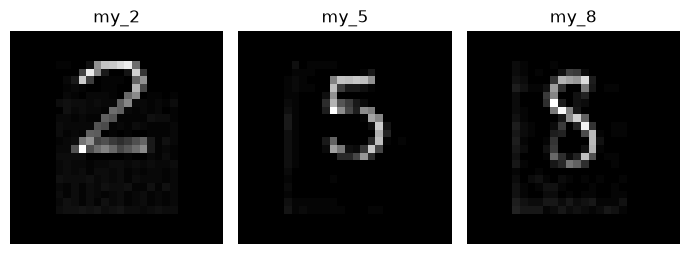

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(7, 3))

for ax, img, path in zip(axes, processed_images, image_paths):
    ax.imshow(img, cmap="gray")
    ax.set_title(path.stem)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [49]:
X_own = np.array([
    img.reshape(784)
    for img in processed_images
])

X_own = scaler.transform(X_own)

predictions = model.predict(X_own)

for path, prediction in zip(image_paths, predictions):
    print(f"{path.name} -> modellen predikterar: {prediction}")

my_2.jpg -> modellen predikterar: 5
my_5.jpg -> modellen predikterar: 7
my_8.jpg -> modellen predikterar: 7



### Slutsats

Modellen fick hög accuracy på MNIST-datan men klassificerade inte mina egna bilder korrekt.

De egna bilderna skiljer sig från MNIST eftersom de kommer från mobilfoton med annan handstil, bakgrund och linjer på pappret. Trots preprocessing blir datan därför inte helt lik den data modellen tränades på.

Det visar att en modell kan prestera bra på testdata men ändå få problem när ny data har en annan fördelning eller utformning.